# Actividad 5 — Extracción de Características

## Análisis univariado y categorización mediante Sturges

**Fuente:** hojas de archivos Excel (`.xlsx` o `.xls`)

Este notebook carga todas las hojas no vacías de los archivos Excel disponibles en la carpeta de trabajo y las combina en una sola base para la actividad.

Se realizan:
1. Verificación de la calidad de los datos.
2. Análisis univariado de 10 variables categóricas mediante tablas y gráficas.
3. Extracción de características estadísticas.
4. Categorización mediante la regla de Sturges de las 8 variables solicitadas.
5. Tablas de frecuencia y gráficas para las categorías obtenidas.
6. Exportación de resultados a archivos CSV.

## 1. Librerías

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

display = print

## 2. Carga de ventas y existencias

Se cargan las hojas `Ventas_CLV_2022_2026` y `Existencias_04_09_2026`, y se unen mediante `articulo_id`.

In [44]:
archivo = "Datos_CLV_2026_Tec_v2.xlsx"

ventas = pd.read_excel(archivo, sheet_name="Ventas_CLV_2022_2026")
existencias = pd.read_excel(archivo, sheet_name="Existencias_04_09_2026")

ventas["fecha_documento"] = pd.to_datetime(
    ventas["fecha_documento"], errors="coerce"
)

nulos_antes = pd.concat({
    "Ventas": ventas.isna().sum(),
    "Existencias": existencias.isna().sum()
})

outliers_antes = {}
for nombre, datos in {"Ventas": ventas, "Existencias": existencias}.items():
    for columna in datos.select_dtypes(include="number"):
        q1 = datos[columna].quantile(0.25)
        q3 = datos[columna].quantile(0.75)
        iqr = q3 - q1
        limite_inferior = q1 - 1.5 * iqr
        limite_superior = q3 + 1.5 * iqr
        outliers_antes[f"{nombre} - {columna}"] = int(
            ((datos[columna] < limite_inferior) |
             (datos[columna] > limite_superior)).sum()
        )

for datos in (ventas, existencias):
    for columna in datos.select_dtypes(include="number"):
        datos[columna] = datos[columna].fillna(datos[columna].median())
        q1 = datos[columna].quantile(0.25)
        q3 = datos[columna].quantile(0.75)
        iqr = q3 - q1
        datos[columna] = datos[columna].clip(q1 - 1.5 * iqr, q3 + 1.5 * iqr)

    for columna in datos.select_dtypes(include="object"):
        datos[columna] = datos[columna].fillna("Sin dato")

ventas["fecha_documento"] = ventas["fecha_documento"].fillna(
    ventas["fecha_documento"].mode().iloc[0]
)
ventas["fecha_documento"] = ventas["fecha_documento"].dt.to_period("M").astype(str)

base = ventas.merge(
    existencias,
    on="articulo_id",
    how="left",
    suffixes=("", "_existencias")
)

for columna in ("existencias", "valor_total_inventario"):
    base[columna] = base[columna].fillna(0)

for columna in base.select_dtypes(include="object"):
    base[columna] = base[columna].fillna("Sin dato")

print(f"Registros: {len(base)}")
print(f"Columnas: {len(base.columns)}")
display(base.head())

Registros: 114501
Columnas: 20
  fecha_documento folio_abreviado      folio  articulo_id clave_articulo  \
0         2026-11             B00  B00013017    7,688.000      MFTL374M2   
1         2026-11             B00  B00013017    7,895.000   MFTPL313R2.5   
2         2026-11             B00  B00013017    7,985.000   MFTPU313R2.5   
3         2026-11             B00  B00013017    8,258.000      MFTT464M2   
4         2026-11             A00  A00018080    7,613.000      MFTL332M2   

  nombre_articulo marca  precio_unitario  total_unidades  total_neto  \
0     MFT L37 4M2  VITA          172.414           1.000     172.410   
1  MFT PL31 3R2.5  VITA          172.414           1.000     172.410   
2  MFT PU31 3R2.5  VITA          172.414           2.000     344.830   
3     MFT T46 4M2  VITA          172.414           2.000     344.830   
4     MFT L33 2M2  VITA          156.740           1.000     156.740   

              nombre_cliente            estado     ciudad         cp  \
0  HUGO

C:\Users\aomp2\AppData\Local\Temp\ipykernel_37332\3786252359.py:36: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for columna in datos.select_dtypes(include="object"):
C:\Users\aomp2\AppData\Local\Temp\ipykernel_37332\3786252359.py:36: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide

## 3. Comprobación de la limpieza de los datos

Se comprueba la cantidad de valores nulos y duplicados de la base combinada para dejar evidencia en el notebook.

In [ ]:
print("Valores nulos antes del preprocesamiento:")
display(nulos_antes[nulos_antes > 0].sort_values(ascending=False))

print("Outliers detectados antes del preprocesamiento:")
display(pd.Series(outliers_antes).loc[lambda serie: serie > 0])

print("Valores nulos después del preprocesamiento:")
display(base.isna().sum().loc[lambda serie: serie > 0])

print(f"Registros duplicados: {base.duplicated().sum()}")

Valores nulos antes del preprocesamiento:
Ventas  fecha_documento    74953
        cp                  5188
dtype: int64
Outliers detectados antes del preprocesamiento:
Ventas - articulo_id                    13923
Ventas - precio_unitario                 9418
Ventas - total_unidades                 16371
Ventas - total_neto                     11515
Ventas - cp                                 5
Existencias - articulo_id                 306
Existencias - existencias                 408
Existencias - valor_total_inventario      456
dtype: int64
Valores nulos después del preprocesamiento:
Series([], dtype: int64)
Registros duplicados: 1761


## 4. Análisis univariado de variables categóricas

Se analizan `fecha_documento`, `nombre_articulo`, `marca`, `nombre_cliente`, `estado`, `vendedor` y `marca` de existencias.

In [45]:
variables_categoricas = [
    "fecha_documento",
    "nombre_articulo",
    "marca",
    "nombre_cliente",
    "estado",
    "vendedor",
    "marca_existencias"
]

variables_categoricas = [
    columna for columna in variables_categoricas
    if columna in base.columns
]

print("Variables categóricas analizadas:")
for columna in variables_categoricas:
    print(f"- {columna}")

Variables categóricas analizadas:
- fecha_documento
- nombre_articulo
- marca
- nombre_cliente
- estado
- vendedor
- marca_existencias


### 4.1 Características estadísticas de las variables categóricas

In [ ]:
resultados_categoricos = []

for columna in variables_categoricas:
    serie = base[columna].astype("string").fillna("Sin dato")
    frecuencias = serie.value_counts(dropna=False)

    resultados_categoricos.append({
        "Variable": columna,
        "N": len(serie),
        "Categorías únicas": int(serie.nunique(dropna=False)),
        "Moda": str(frecuencias.index[0]),
        "Frecuencia de la moda": int(frecuencias.iloc[0]),
        "Porcentaje de la moda": round(
            frecuencias.iloc[0] / len(serie) * 100, 2
        )
    })

tabla_resumen_categoricas = pd.DataFrame(resultados_categoricos)

display(tabla_resumen_categoricas)

            Variable       N  Categorías únicas                       Moda  \
0    fecha_documento  114501                 48                    2024-12   
1    nombre_articulo  114501               3895  FRESA ROTO RFID 1.0 ZI DM   
2              marca  114501                 34                       VITA   
3     nombre_cliente  114501               4743                 EURODENTAL   
4             estado  114501                 51           Ciudad de México   
5           vendedor  114501                139                      DIEGO   
6  marca_existencias  114501                 21                       Vita   

   Frecuencia de la moda  Porcentaje de la moda  
0                  76637                 66.930  
1                   1703                  1.490  
2                  59107                 51.620  
3                   4690                  4.100  
4                  24337                 21.250  
5                  12480                 10.900  
6                  45065 

### 4.2 Tablas de frecuencia

In [ ]:
tablas_frecuencia_categoricas = {}

for columna in variables_categoricas:
    serie = base[columna].astype("string").fillna("Sin dato")

    tabla = (
        serie.value_counts(dropna=False)
        .rename_axis("Categoría")
        .reset_index(name="Frecuencia")
    )

    tabla["Porcentaje"] = (
        tabla["Frecuencia"] / len(serie) * 100
    ).round(2)

    tablas_frecuencia_categoricas[columna] = tabla

    print(f"\n### Tabla de frecuencia — {columna}")
    display(tabla)


### Tabla de frecuencia — fecha_documento
   Categoría  Frecuencia  Porcentaje
0    2024-12       76637      66.930
1    2024-11        1281       1.120
2    2023-08        1268       1.110
3    2024-09        1193       1.040
4    2026-09        1121       0.980
5    2025-11        1116       0.970
6    2024-04        1096       0.960
7    2023-06        1085       0.950
8    2025-10        1084       0.950
9    2024-02        1083       0.950
10   2024-08        1007       0.880
11   2023-05        1004       0.880
12   2025-12         985       0.860
13   2025-04         950       0.830
14   2025-09         944       0.820
15   2023-10         933       0.810
16   2023-11         928       0.810
17   2024-05         921       0.800
18   2023-12         910       0.790
19   2025-08         903       0.790
20   2025-05         890       0.780
21   2025-02         825       0.720
22   2024-07         791       0.690
23   2023-09         778       0.680
24   2023-04         768       0

### 4.3 Gráficas de las variables categóricas

Se genera una gráfica independiente para cada variable. Cuando una variable tiene muchas categorías, la gráfica muestra las 15 categorías con mayor frecuencia para mantener la visualización legible; la tabla anterior conserva todas las categorías.


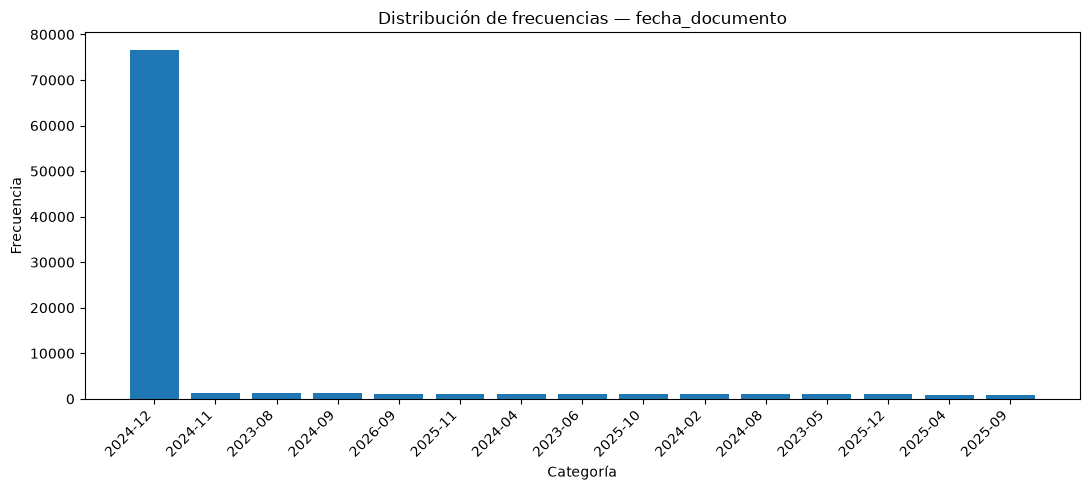

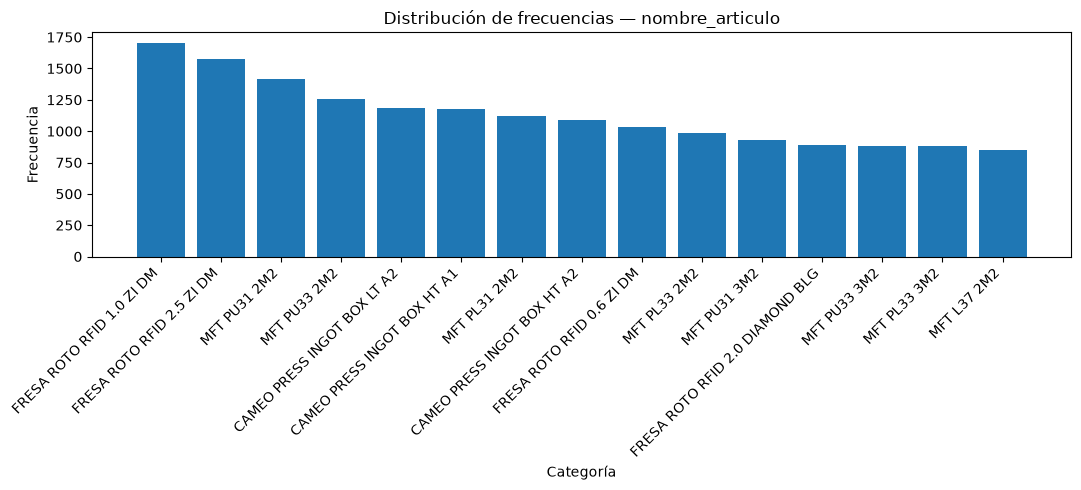

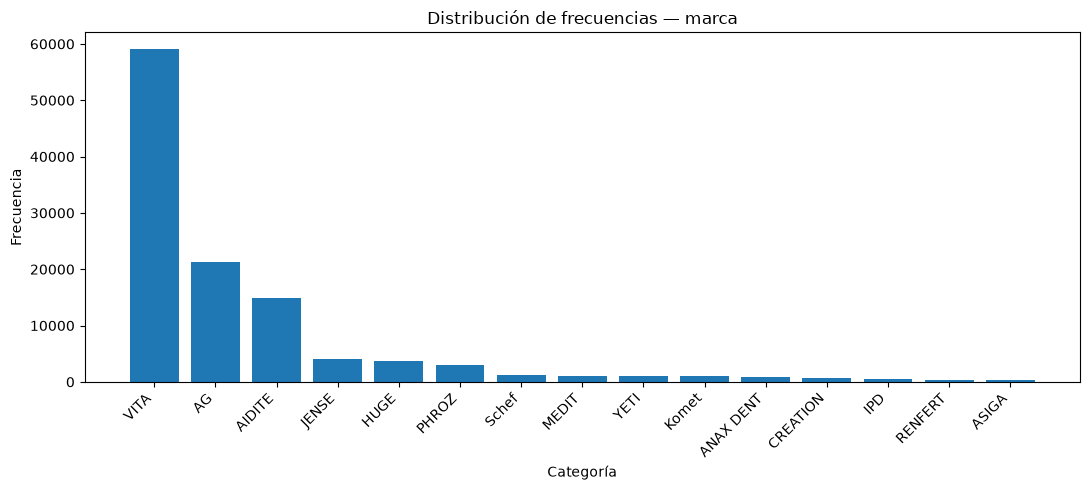

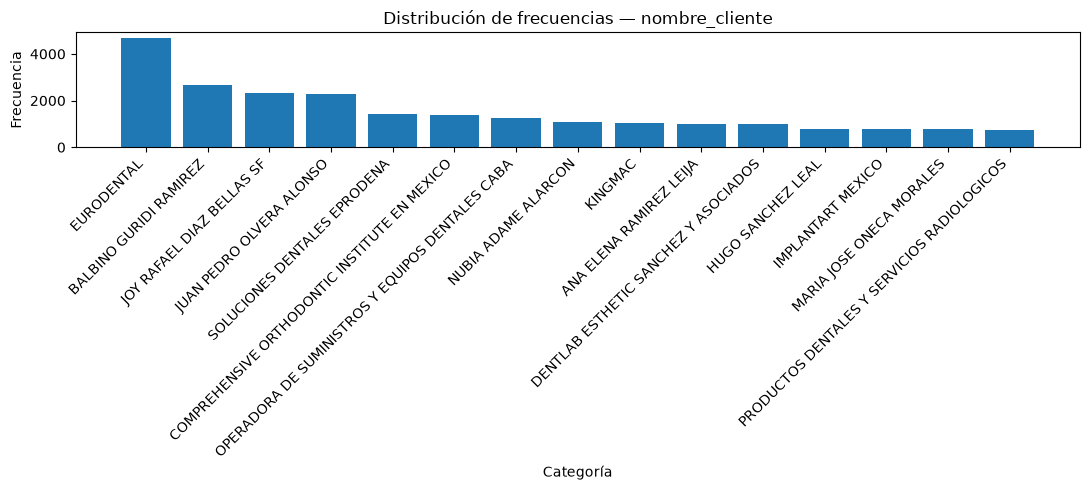

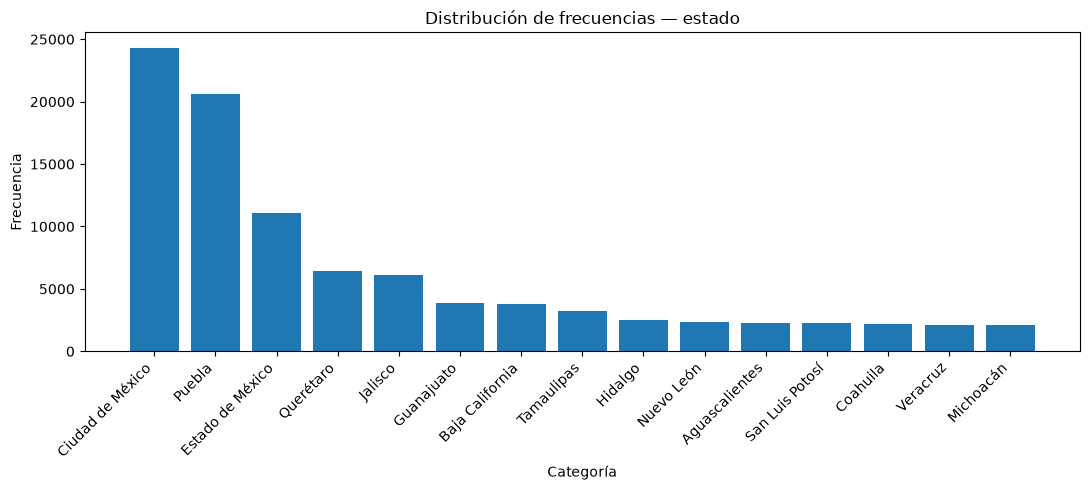

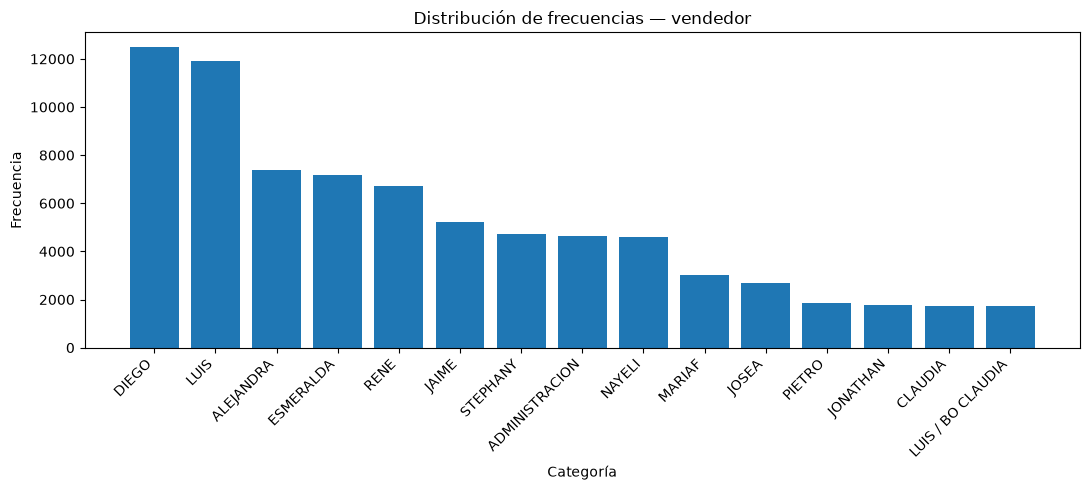

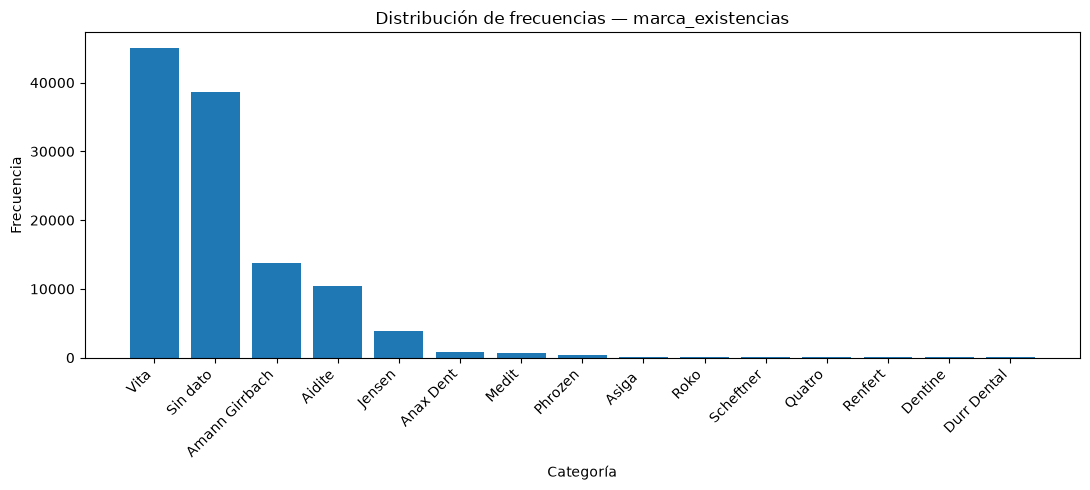

In [32]:
for columna in variables_categoricas:
    tabla = tablas_frecuencia_categoricas[columna]
    tabla_grafica = tabla.head(15)

    plt.figure(figsize=(11, 5))
    plt.bar(
        tabla_grafica["Categoría"].astype(str),
        tabla_grafica["Frecuencia"]
    )
    plt.title(f"Distribución de frecuencias — {columna}")
    plt.xlabel("Categoría")
    plt.ylabel("Frecuencia")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


## 5. Extracción de características estadísticas

Para las variables numéricas se obtienen medidas de tendencia central, dispersión y forma de la distribución.


In [ ]:
# Variables numéricas disponibles en la base.
columnas_numericas = base.select_dtypes(
    include=np.number
).columns.tolist()

print(f"Variables numéricas encontradas: {len(columnas_numericas)}")
print(columnas_numericas)

Variables numéricas encontradas: 7
['articulo_id', 'precio_unitario', 'total_unidades', 'total_neto', 'cp', 'existencias', 'valor_total_inventario']


In [ ]:
# Resumen estadístico general de las variables numéricas.
if columnas_numericas:
    tabla_descriptiva_general = base[columnas_numericas].describe().T
    display(tabla_descriptiva_general)
else:
    tabla_descriptiva_general = pd.DataFrame()
    print("No se encontraron variables numéricas.")

                             count       mean        std       min        25%  \
articulo_id            114,501.000 46,008.971 68,822.543 3,458.000  7,664.000   
precio_unitario        114,501.000    728.995    771.692     0.000    163.793   
total_unidades         114,501.000      1.660      0.948     1.000      1.000   
total_neto             114,501.000  1,245.501  1,370.642     0.000    181.030   
cp                     114,501.000 50,103.378 27,653.687    57.000 22,500.000   
existencias            114,501.000     17.209     15.323     0.000      0.000   
valor_total_inventario 114,501.000  6,177.992  6,383.768     0.000      0.000   

                              50%        75%         max  
articulo_id             8,099.000 85,841.000 203,106.500  
precio_unitario           297.413  1,120.690   2,556.034  
total_unidades              1.000      2.000       3.500  
total_neto                638.800  1,816.380   4,269.405  
cp                     55,075.000 72,470.000 147,425.000

In [46]:
variables_sturges = [
    "existencias",
    "precio_unitario",
    "total_unidades",
    "total_neto",
    "valor_total_inventario"
]

variables_sturges = [
    columna for columna in variables_sturges
    if columna in base.columns
]

estado_variables = pd.DataFrame({
    "Variable": variables_sturges,
    "Disponible": True
})

display(estado_variables)
print(f"Variables numéricas analizadas: {len(variables_sturges)}")

                 Variable  Disponible
0             existencias        True
1         precio_unitario        True
2          total_unidades        True
3              total_neto        True
4  valor_total_inventario        True
Variables numéricas analizadas: 5


## 7. Estadística descriptiva de las variables numéricas seleccionadas

In [ ]:
caracteristicas_estadisticas = []

for columna in variables_sturges:
    serie = pd.to_numeric(base[columna], errors="coerce")
    valores = serie.dropna()
    moda = valores.mode()

    caracteristicas_estadisticas.append({
        "Variable": columna,
        "N válidos": len(valores),
        "N faltantes": int(serie.isna().sum()),
        "Media": valores.mean(),
        "Mediana": valores.median(),
        "Moda": moda.iloc[0] if not moda.empty else np.nan,
        "Desviación estándar": valores.std(),
        "Varianza": valores.var(),
        "Mínimo": valores.min(),
        "Q1": valores.quantile(0.25),
        "Q3": valores.quantile(0.75),
        "Máximo": valores.max(),
        "Rango": valores.max() - valores.min(),
        "RIC": valores.quantile(0.75) - valores.quantile(0.25),
        "Asimetría": valores.skew(),
        "Curtosis": valores.kurt()
    })

tabla_caracteristicas = pd.DataFrame(caracteristicas_estadisticas)

display(tabla_caracteristicas.round(3))

                 Variable  N válidos  N faltantes     Media   Mediana  \
0             existencias     114501            0    17.209    19.000   
1         precio_unitario     114501            0   728.995   297.413   
2          total_unidades     114501            0     1.660     1.000   
3              total_neto     114501            0 1,245.501   638.800   
4  valor_total_inventario     114501            0 6,177.992 3,407.350   

       Moda  Desviación estándar       Varianza  Mínimo      Q1         Q3  \
0    33.000               15.323        234.809   0.000   0.000     33.000   
1 2,556.034              771.692    595,509.273   0.000 163.793  1,120.690   
2     1.000                0.948          0.898   1.000   1.000      2.000   
3 4,269.405            1,370.642  1,878,660.004   0.000 181.030  1,816.380   
4     0.000            6,383.768 40,752,499.757   0.000   0.000 14,823.908   

      Máximo      Rango        RIC  Asimetría  Curtosis  
0     33.000     33.000     33.000

## 8. Regla de Sturges

La regla se aplica a las variables numéricas seleccionadas después del tratamiento de nulos y outliers.

In [ ]:
resultados_sturges = {}
frecuencias_sturges = {}
tablas_sturges_detalladas = {}

for columna in variables_sturges:
    serie = pd.to_numeric(base[columna], errors="coerce")
    valores = serie.dropna()

    n = len(valores)
    k = max(1, int(np.ceil(1 + 3.322 * np.log10(n))))
    minimo = valores.min()
    maximo = valores.max()

    if minimo == maximo:
        categorias = pd.Series(
            ["Categoría única"] * len(serie),
            index=serie.index,
            dtype="string"
        )
        ancho = 0
        limites = [minimo, maximo]
        etiquetas = ["Categoría única"]
    else:
        limites = np.linspace(minimo, maximo, k + 1)
        etiquetas = [f"Intervalo {i}" for i in range(1, k + 1)]
        categorias = pd.cut(
            serie,
            bins=limites,
            labels=etiquetas,
            include_lowest=True
        )
        ancho = (maximo - minimo) / k

    base[f"{columna}_categoria"] = categorias
    frecuencias = categorias.value_counts(sort=False, dropna=False)

    tabla_detallada = pd.DataFrame({
        "Intervalo": etiquetas,
        "Frecuencia": frecuencias.reindex(
            etiquetas, fill_value=0
        ).astype(int).values
    })

    if minimo != maximo:
        tabla_detallada["Límite inferior"] = limites[:-1]
        tabla_detallada["Límite superior"] = limites[1:]

    tablas_sturges_detalladas[columna] = tabla_detallada
    frecuencias_sturges[columna] = frecuencias
    resultados_sturges[columna] = {
        "N": n,
        "Número de intervalos (k)": k,
        "Mínimo": minimo,
        "Máximo": maximo,
        "Ancho del intervalo": ancho
    }

tabla_sturges = pd.DataFrame(resultados_sturges).T
display(tabla_sturges.round(3))

                                 N  Número de intervalos (k)  Mínimo  \
existencias            114,501.000                    18.000   0.000   
precio_unitario        114,501.000                    18.000   0.000   
total_unidades         114,501.000                    18.000   1.000   
total_neto             114,501.000                    18.000   0.000   
valor_total_inventario 114,501.000                    18.000   0.000   

                           Máximo  Ancho del intervalo  
existencias                33.000                1.833  
precio_unitario         2,556.034              142.002  
total_unidades              3.500                0.139  
total_neto              4,269.405              237.189  
valor_total_inventario 14,823.908              823.550  


In [ ]:
rangos_sturges = []

for columna in variables_sturges:
    minimo = resultados_sturges[columna]["Mínimo"]
    maximo = resultados_sturges[columna]["Máximo"]
    tabla = tablas_sturges_detalladas[columna]

    for _, fila in tabla.iterrows():
        rangos_sturges.append({
            "Variable": columna,
            "Mínimo": minimo,
            "Máximo": maximo,
            "Rango global": maximo - minimo,
            "Intervalo": fila["Intervalo"],
            "Límite inferior": fila.get("Límite inferior", minimo),
            "Límite superior": fila.get("Límite superior", maximo),
            "Frecuencia": fila["Frecuencia"]
        })

tabla_rangos_sturges = pd.DataFrame(rangos_sturges)
display(tabla_rangos_sturges.round(3))

                  Variable  Mínimo     Máximo  Rango global     Intervalo  \
0              existencias   0.000     33.000        33.000   Intervalo 1   
1              existencias   0.000     33.000        33.000   Intervalo 2   
2              existencias   0.000     33.000        33.000   Intervalo 3   
3              existencias   0.000     33.000        33.000   Intervalo 4   
4              existencias   0.000     33.000        33.000   Intervalo 5   
5              existencias   0.000     33.000        33.000   Intervalo 6   
6              existencias   0.000     33.000        33.000   Intervalo 7   
7              existencias   0.000     33.000        33.000   Intervalo 8   
8              existencias   0.000     33.000        33.000   Intervalo 9   
9              existencias   0.000     33.000        33.000  Intervalo 10   
10             existencias   0.000     33.000        33.000  Intervalo 11   
11             existencias   0.000     33.000        33.000  Intervalo 12   

## 9. Frecuencias de las categorías obtenidas mediante Sturges

In [ ]:
tabla_frecuencias_sturges = pd.DataFrame({
    columna: frecuencias_sturges[columna].reindex(
        base[f"{columna}_categoria"].cat.categories
        if hasattr(base[f"{columna}_categoria"], "cat")
        else frecuencias_sturges[columna].index,
        fill_value=0
    ).astype(int).values
    for columna in variables_sturges
})

display(tabla_frecuencias_sturges)

    existencias  precio_unitario  total_unidades  total_neto  \
0         41749            17783           71357       33060   
1          3195            38582               0       17382   
2          2120             4192               0        9941   
3          1972             4606               0        7789   
4          2118             4552               0        6168   
5          1626             3287               0        6461   
6           717             7810               0        2796   
7          1185             7046           18915        3075   
8          1402             2408               0        2418   
9           622             6790               0        2643   
10         1516             1456               0        2814   
11         1033             1246               0        1771   
12          277              724               0        1480   
13         1466             1307               0         994   
14         1459              677        

## 10. Gráficas de frecuencia para las 8 variables categorizadas con Sturges

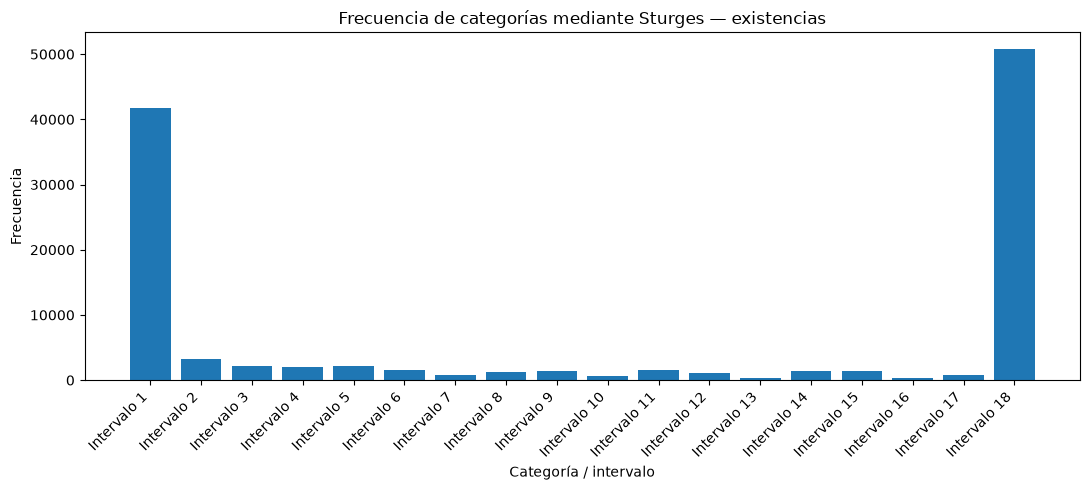

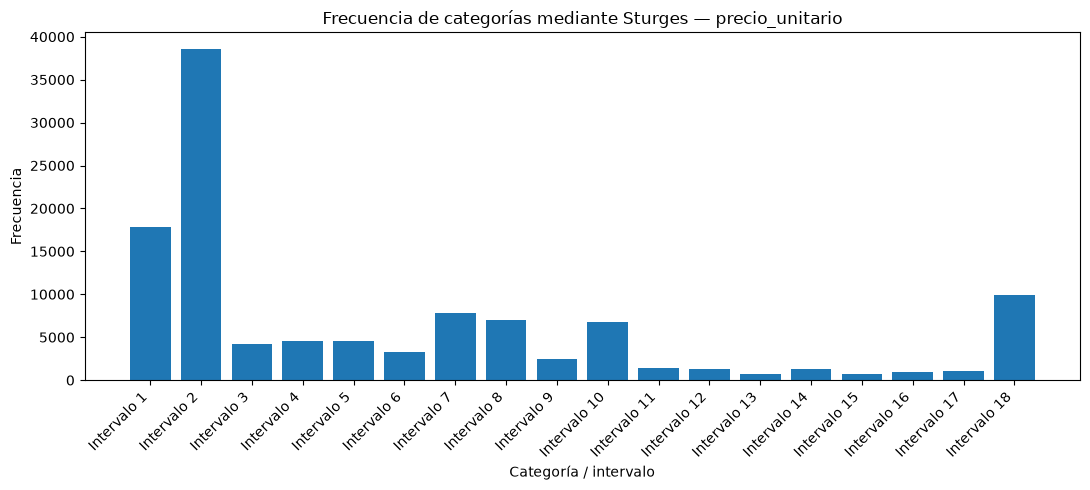

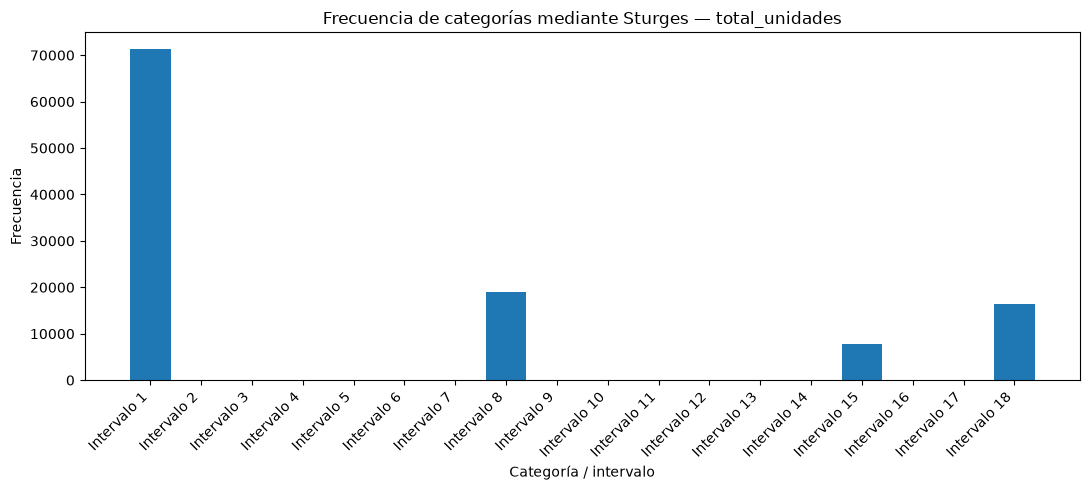

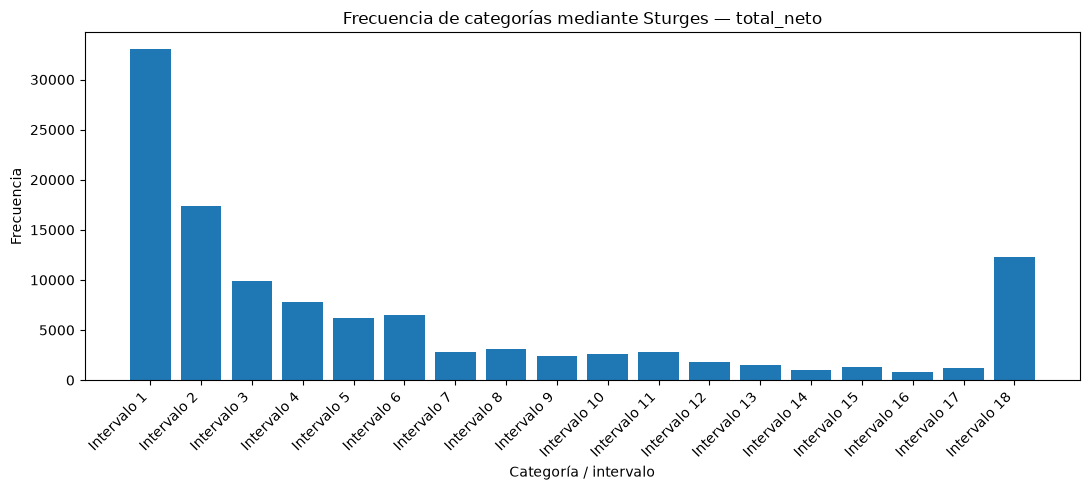

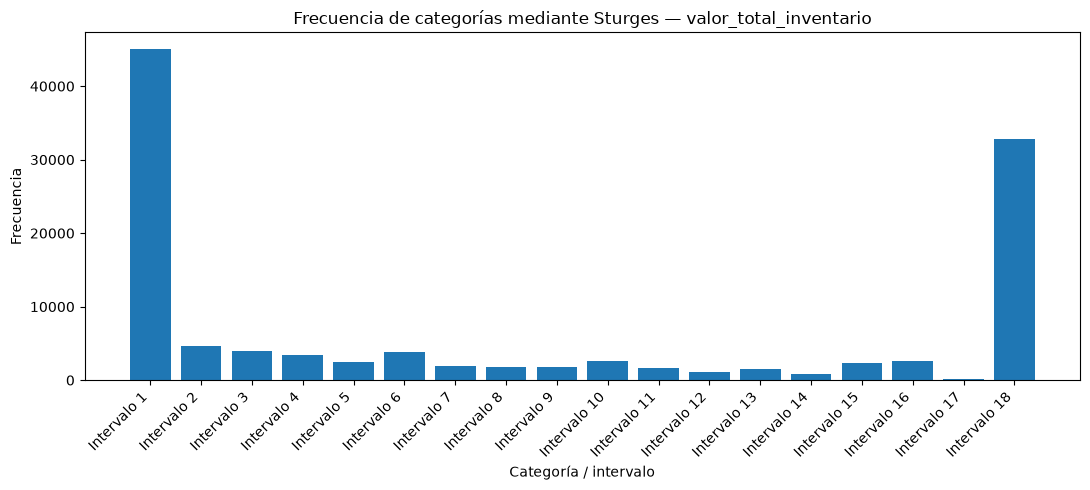

In [40]:
for columna in variables_sturges:
    tabla = tablas_sturges_detalladas[columna]

    plt.figure(figsize=(11, 5))
    plt.bar(
        tabla["Intervalo"].astype(str),
        tabla["Frecuencia"]
    )
    plt.title(
        f"Frecuencia de categorías mediante Sturges — {columna}"
    )
    plt.xlabel("Categoría / intervalo")
    plt.ylabel("Frecuencia")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


## 11. Interpretación automática de los resultados

Esta sección identifica el intervalo con mayor frecuencia para cada variable. La interpretación final puede complementarse con las tablas y gráficas anteriores.


In [ ]:
interpretaciones_sturges = []

for columna in variables_sturges:
    tabla = tablas_sturges_detalladas[columna]
    fila = tabla.loc[tabla["Frecuencia"].idxmax()]

    interpretaciones_sturges.append({
        "Variable": columna,
        "Categoría más frecuente": fila["Intervalo"],
        "Frecuencia": int(fila["Frecuencia"]),
        "Porcentaje": round(
            fila["Frecuencia"] / len(base) * 100,
            2
        )
    })

tabla_interpretacion_sturges = pd.DataFrame(
    interpretaciones_sturges
)

display(tabla_interpretacion_sturges)

                 Variable Categoría más frecuente  Frecuencia  Porcentaje
0             existencias            Intervalo 18       50811      44.380
1         precio_unitario             Intervalo 2       38582      33.700
2          total_unidades             Intervalo 1       71357      62.320
3              total_neto             Intervalo 1       33060      28.870
4  valor_total_inventario             Intervalo 1       45074      39.370
